# Bitcoin: predicting tomorrow's 24 hourly price changes
### Models, hyperparameters and evaluation (new preprocessed data)

This notebook uses the new output of the data preparation step: `btc_hourly_windows.npz` and `scaler.joblib`. Put both files in the same folder as the notebook.

**The task.** Each sample is one week of hourly data (168 hours × 6 columns: Open, High, Low, Close, Volume, Return). The model must predict the 24 hourly price changes of the next day, where each value is `Close[h] / Close[h-1] − 1`.

**Structure**

1. Load the new data and check what it contains.
2. Decisions taken from those checks (each one justified).
3. Model inputs: turning each standardized window into scale-free features.
4. Metrics: what each one means and what values to expect.
5. Validation method: walk-forward cross-validation + a final untouched test period + a significance check.
6. Baselines.
7. Models and hyperparameters: Ridge, Lasso, k-Nearest Neighbors, Random Forest, Gradient Boosting, optional small MLP.
8. Experiment: how much history should we train on?
9. Final comparison on the test period.
10. Better targets: next-day total return, next-day direction, next-day volatility.
11. Conclusions.

All models are standard scikit-learn models: we only choose their hyperparameters.

## 1. Load the new data

In [1]:
import time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from scipy.stats import binomtest, spearmanr

from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier,
                              HistGradientBoostingRegressor, HistGradientBoostingClassifier)
from sklearn.multioutput import MultiOutputRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import ParameterGrid, TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score, accuracy_score,
                             balanced_accuracy_score, roc_auc_score, log_loss)
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", message=".*Trying to unpickle.*")
RANDOM_STATE = 42

data = np.load("data/btc_hourly_windows.npz")
X_train, X_test = data["X_train"], data["X_test"]
y_train, y_test = data["y_train"], data["y_test"]
dates_train = pd.to_datetime(data["dates_train"])
dates_test = pd.to_datetime(data["dates_test"])
feature_cols = list(data["feature_cols"])

scaler = joblib.load("data/scaler.joblib")      # StandardScaler fitted by the data-preparation step
SC_MEAN, SC_SCALE = scaler.mean_, scaler.scale_
INPUT_HOURS, TARGET_HOURS = X_train.shape[1], y_train.shape[1]

print("X_train", X_train.shape, " y_train", y_train.shape, f" {dates_train[0]} -> {dates_train[-1]}")
print("X_test ", X_test.shape,  " y_test ", y_test.shape,  f" {dates_test[0]} -> {dates_test[-1]}")
print("features:", feature_cols)

X_train (103356, 168, 6)  y_train (103356, 24)  2012-01-09 00:00:00 -> 2023-10-24 11:00:00
X_test  (25839, 168, 6)  y_test  (25839, 24)  2023-10-24 12:00:00 -> 2026-10-05 02:00:00
features: [np.str_('Open'), np.str_('High'), np.str_('Low'), np.str_('Close'), np.str_('Volume'), np.str_('Return')]


### What the files contain

- `X_*`: windows of 168 hours × 6 columns, **standardized** with the `StandardScaler` in `scaler.joblib` (fitted on the training windows only, so no test information leaks into it).
- `y_*`: 24 values per window, **not scaled**. `y[i, h]` is the simple return of hour *h* of the next day: `Close[h] / Close[h-1] − 1`. A value of 0.004 means +0.4%.
- `dates_*`: the timestamp of the **last** of the 24 target hours. (The last test date is today, so it cannot be the start of the target day.)

The next cell verifies these facts instead of assuming them, and looks at how train and test differ.

y_train[i] == Return of the hours after window i: True
Last training target is inside the inputs of test window 23: True -> the first test targets overlap the last training targets

Scaled Close  train: -0.72 to 3.81   test: 1.13 to 7.60


,mean_abs_return_%,share_zero_hours,up_day
year,,,
2012,0.583,0.478,0.528
2013,0.920,0.052,0.636
2014,0.568,0.009,0.468
2015,0.421,0.022,0.499
2016,0.281,0.014,0.587
2017,0.707,0.003,0.619
2018,0.576,0.002,0.510
2019,0.412,0.000,0.512
2020,0.435,0.001,0.582


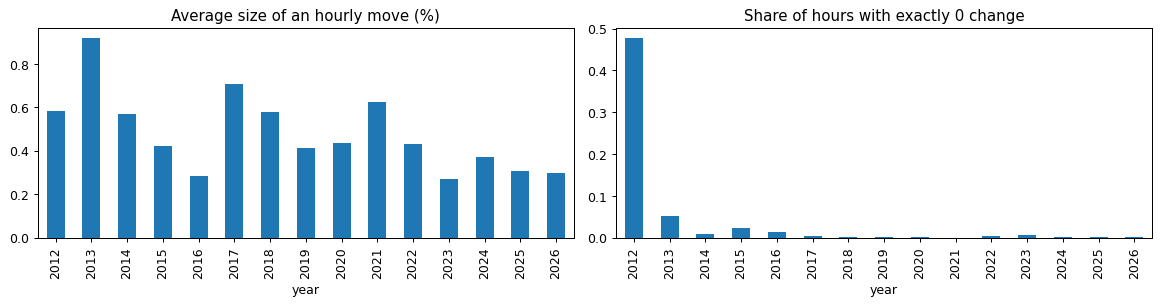

In [2]:
ret_idx, close_idx = feature_cols.index("Return"), feature_cols.index("Close")

def unscale(X, j):
    # undo the StandardScaler for column j
    return X[..., j].astype(np.float64) * SC_SCALE[j] + SC_MEAN[j]

# 1) y[i] is exactly the "Return" column 24 windows later (windows move 1 hour at a time)
r_tr = unscale(X_train[24:2024], ret_idx)
print("y_train[i] == Return of the hours after window i:",
      np.allclose(y_train[:2000], r_tr[:, -24:], atol=1e-6))

# 2) overlap between the end of train and the start of test
r_te = unscale(X_test[:30], ret_idx)
print("Last training target is inside the inputs of test window 23:",
      np.allclose(y_train[-1], r_te[23, -24:], atol=1e-6),
      "-> the first test targets overlap the last training targets")

# 3) Scaled prices: train vs test
c_tr, c_te = X_train[::24, :, close_idx], X_test[::24, :, close_idx]
print(f"\nScaled Close  train: {c_tr.min():.2f} to {c_tr.max():.2f}   test: {c_te.min():.2f} to {c_te.max():.2f}")

# 4) Behaviour of the target by year (one non-overlapping day per window, stride 24)
all_y = np.concatenate([y_train[::24], y_test[::24]])
all_d = np.concatenate([dates_train[::24], dates_test[::24]])
yearly = pd.DataFrame({
    "year": pd.DatetimeIndex(all_d).year,
    "mean_abs_return_%": np.abs(all_y).mean(axis=1) * 100,
    "share_zero_hours": (all_y == 0).mean(axis=1),
    "up_day": (np.prod(1 + all_y, axis=1) > 1),
}).groupby("year").mean()
display(yearly.round(3))

fig, ax = plt.subplots(1, 2, figsize=(13, 3.5))
yearly["mean_abs_return_%"].plot.bar(ax=ax[0], title="Average size of an hourly move (%)")
yearly["share_zero_hours"].plot.bar(ax=ax[1], title="Share of hours with exactly 0 change")
plt.tight_layout(); plt.show()

## 2. Decisions taken from the checks

**a) Prices are standardized, but still not usable directly.** Standardizing with one global mean and standard deviation does not remove the trend. The scaled Close in the test period (about 1 to 7.6) lies mostly *above* anything seen in training (max about 3.8). Tree models cannot predict outside the range they were trained on: every test window would look like "the highest price ever seen". Linear models would extrapolate the price level in a meaningless way. **Decision:** undo the scaling with the scaler's `mean_` and `scale_` and build *scale-free* features (returns, ratios, volatility). The `Return` column is already scale-free and can be used directly.

**b) The early years behave differently.** In 2012 about half of the hours have exactly 0 change (almost no trading, so the price was carried forward), and 2012–2013 hourly moves are 2–3× larger than today. A model trained with these years learns patterns of a tiny, illiquid market. **Decision:** train from `TRAIN_START = "2017-01-01"` by default. Section 8 tests this choice instead of just assuming it.

**c) Volatility changes a lot between periods.** The test period (Oct 2023–Oct 2026) is calmer than most of the training period, so raw error values are not comparable between periods. **Decision:** always report errors *relative to a baseline* (the "skill" metrics in section 4) in addition to raw values.

**d) The train/test boundary overlaps.** The first 23 test windows have target hours that were also target hours of the last training window. **Decision:** drop the first 24 test windows ("purging"), so no test target was ever seen during training.

**e) Consecutive windows are almost identical.** Each window shares 167 of its 168 hours with the next one. **Decision:** for training keep every 6th window (`STRIDE = 6`). This makes training ~6× faster and loses almost no information. All test windows are still evaluated.

**f) Units.** Returns are multiplied by 100 so that everything is in **percent** (0.4 means +0.4%). This makes tables much easier to read.

## 3. Model inputs: scale-free features

Each window is turned into 42 numbers. All of them mean the same thing in 2017 and in 2026, which is what makes it possible to learn from the past and apply it to the present.

| Group | Features | Idea |
|---|---|---|
| Recent returns | 24 hourly returns, lag 1 (most recent) to lag 24 | short-term momentum or reversal |
| Return statistics | mean and standard deviation of returns over 24h, 72h, 168h | trend and volatility at three time scales |
| Price position | 24h return, 7-day return, position of the last close in the week's high–low range, distance to the week's average close | where the price stands relative to its recent past |
| Intra-hour range | average (High − Low) / Close over 24h and 168h | another volatility measure |
| Volume | log volume of last 24h vs. the week, last hour vs. the week | unusual activity |
| Calendar | hour of day and day of week of the forecast start (as sine/cosine) | trading-session and weekend patterns |

Hour and weekday are encoded as sine/cosine so that 23:00 is close to 00:00 and Sunday is close to Monday.

A second, simpler option is `FEATURE_SET = "returns_only"`: just the 168 hourly returns of the week.

In [3]:
FEATURE_SET = "engineered"      # "engineered" or "returns_only"
STRIDE = 6                      # keep every 6th training window
TRAIN_START = "2017-01-01"      # see decision (b) and section 8

def window_returns(X):
    # hourly returns of the 168 input hours, in %
    return unscale(X, ret_idx) * 100

def make_features(X, dates, feature_set=FEATURE_SET):
    ret = window_returns(X)
    if feature_set == "returns_only":
        return ret, [f"ret_lag{168 - i}" for i in range(168)]
    eps = 1e-12
    close = unscale(X, feature_cols.index("Close"))
    high  = unscale(X, feature_cols.index("High"))
    low   = unscale(X, feature_cols.index("Low"))
    vol   = np.log1p(np.maximum(unscale(X, feature_cols.index("Volume")), 0))
    last = close[:, -1]

    feats, names = [ret[:, ::-1][:, :24]], [f"ret_lag{k}" for k in range(1, 25)]
    for w in (24, 72, 168):
        feats += [ret[:, -w:].mean(1, keepdims=True), ret[:, -w:].std(1, keepdims=True)]
        names += [f"ret_mean_{w}h", f"ret_std_{w}h"]
    hi, lo = high.max(1), low.min(1)
    hl = (high - low) / close * 100
    extra = {
        "ret_24h": (last / close[:, -25] - 1) * 100,
        "ret_7d": (last / close[:, 0] - 1) * 100,
        "pos_in_week_range": (last - lo) / (hi - lo + eps),
        "dist_to_week_mean": (last / close.mean(1) - 1) * 100,
        "hl_range_24h": hl[:, -24:].mean(1),
        "hl_range_168h": hl.mean(1),
        "volume_24h_vs_week": vol[:, -24:].mean(1) - vol.mean(1),
        "volume_last_vs_week": vol[:, -1] - vol.mean(1),
    }
    start = pd.DatetimeIndex(dates) - pd.Timedelta(hours=TARGET_HOURS - 1)   # first predicted hour
    extra["hour_sin"] = np.sin(2 * np.pi * start.hour / 24)
    extra["hour_cos"] = np.cos(2 * np.pi * start.hour / 24)
    extra["dow_sin"] = np.sin(2 * np.pi * start.dayofweek / 7)
    extra["dow_cos"] = np.cos(2 * np.pi * start.dayofweek / 7)
    feats += [np.asarray(v)[:, None] for v in extra.values()]
    names += list(extra)
    return np.hstack(feats), names

# ---- Training data: every STRIDE-th window of the whole training period (filtered by TRAIN_START later) ----
idx_all = np.arange(0, len(X_train), STRIDE)
F_all, feature_names = make_features(X_train[idx_all], dates_train[idx_all])
Y_all = y_train[idx_all] * 100
D_all = dates_train[idx_all]
R_all = window_returns(X_train[idx_all])           # raw input returns (used by some baselines)

def training_set(start=TRAIN_START):
    m = np.ones(len(D_all), bool) if start is None else (D_all >= pd.Timestamp(start))
    return F_all[m], Y_all[m], D_all[m], R_all[m]

Ftr, Ytr, Dtr, Rtr = training_set()

# ---- Test data: all windows, after purging the first 24 (decision d) ----
PURGE = TARGET_HOURS
Fte, _ = make_features(X_test[PURGE:], dates_test[PURGE:])
Yte = y_test[PURGE:] * 100
Dte = dates_test[PURGE:]
Rte = window_returns(X_test[PURGE:])

print(f"Feature set '{FEATURE_SET}': {Ftr.shape[1]} features")
print(f"Training samples: {len(Ftr):>6}  ({Dtr[0].date()} -> {Dtr[-1].date()}, every {STRIDE}th window)")
print(f"Test samples:     {len(Fte):>6}  ({Dte[0].date()} -> {Dte[-1].date()}, all windows)")

Feature set 'engineered': 42 features
Training samples:   9950  (2017-01-01 -> 2023-10-24, every 6th window)
Test samples:      25815  (2023-10-25 -> 2026-10-05, all windows)


## 4. Metrics: what they mean and what values to expect

All values are computed on returns in **percent**. "Zero forecast" means predicting 0% change for every hour.

| Metric | What it measures | Better | Expected on this data |
|---|---|---|---|
| **MAE** | Average absolute error per predicted hour, in %. "On average we miss by x%." | lower | ≈ **0.33%** for the zero forecast on the test period (equal to the average size of an hourly move). Good models land within ±1% of that value. |
| **RMSE** | Square root of the average squared error, in %. Punishes big misses more than MAE. | lower | ≈ **0.50%** (≈ the standard deviation of hourly returns in the test period). |
| **MAE skill** | `1 − MAE_model / MAE_zero`. Share of the zero forecast's error that the model removes. Makes periods with different volatility comparable. | higher | **0** = as good as predicting zero. Realistic: −0.02 to +0.005. Anything clearly above 0.01 would be surprising and worth double-checking for leakage. |
| **R²_oos** | `1 − SSE_model / SSE_zero`: the same idea as MAE skill but with squared errors. It is the usual "out-of-sample R²" in finance; it compares against the zero forecast instead of the test mean (which the model could not know in advance). | higher | Around **0**, often slightly negative. +0.005 is already a good result for hourly returns. |
| **IC** (information coefficient) | Correlation between predicted and actual returns. Measures whether the model ranks hours correctly, even if the size of its predictions is wrong (models usually predict tiny values). | higher | **0** = no information, constant forecasts have none. 0.02–0.05 is considered useful in finance. |
| **Hourly direction accuracy** | Share of hours where the predicted sign (up/down) is right. | higher | **≈ 50%** (coin flip). 51–52% is realistic. |
| **Daily direction accuracy** | The 24 predictions are compounded into one predicted next-day return; share of days where its sign is right. The most intuitive number for a presentation. | higher | **≈ 50%**. Evaluated on non-overlapping days with a significance test (next section). |
| **p-value (daily direction)** | Probability of getting this accuracy or better by pure luck if the true accuracy were 50%. | lower | Above 0.05 means "cannot be told apart from a coin flip". With ≈1,080 test days, accuracy must be above ≈ 52.6% to be significant. |
| **Daily balanced accuracy** | Average of the accuracy on up days and on down days. | higher | **0.50** for any rule that always says the same thing. |

**A trap with direction accuracy.** About 53% of the test days were up days (Bitcoin rose over the period). A model that simply always says "up" therefore gets ≈53% accuracy, and the binomial test even calls it "significant", although it knows nothing about individual days. This is why we also report **balanced accuracy**, which "always up" cannot fool (it scores exactly 0.50), and why every model must be compared with the "mean per hour" baseline, which behaves like "always up".

**Why several metrics?** MAE and RMSE answer "how far off are the numbers?". For returns the honest answer is "about as far off as predicting zero", because hourly moves are mostly noise. IC and direction accuracy answer a different question, "does the model know which way things go?", which can be slightly positive even when MAE does not improve.

**Why we pick hyperparameters by MAE.** MAE is robust to the huge outlier hours in crypto, unlike RMSE. The skill and IC values are reported next to it to see the full picture.

In [4]:
def daily_from_hourly(y_pct):
    # compound 24 hourly % returns into one next-day % return
    return (np.prod(1 + y_pct / 100, axis=1) - 1) * 100

def safe_corr(a, b):
    a, b = np.ravel(a), np.ravel(b)
    return np.nan if np.std(a) < 1e-12 else np.corrcoef(a, b)[0, 1]

def metrics(y_true, y_pred):
    nz = y_true != 0
    mae, mae0 = mean_absolute_error(y_true, y_pred), np.abs(y_true).mean()
    sse, sse0 = ((y_true - y_pred) ** 2).sum(), (y_true ** 2).sum()
    d_true, d_pred = daily_from_hourly(y_true), daily_from_hourly(y_pred)
    return {
        "MAE": mae,
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE_skill": 1 - mae / mae0,
        "R2_oos": 1 - sse / sse0,
        "IC": safe_corr(y_pred, y_true),
        "HourDirAcc": ((y_pred[nz] > 0) == (y_true[nz] > 0)).mean(),
        "DayDirAcc": ((d_pred > 0) == (d_true > 0)).mean(),
    }

## 5. Validation method

The data is a time series, so the evaluation must respect time: a model may only learn from the past and be judged on the future. The process has three layers.

**Layer 1: walk-forward cross-validation for choosing hyperparameters (training period only).**
The training period (2017 → Oct 2023) is split into 5 consecutive blocks. Fold 1 trains on block 1 and validates on block 2; fold 2 trains on blocks 1–2 and validates on block 3; and so on. Every hyperparameter setting is scored by the **average validation MAE skill over the 4 folds** (with its standard deviation across folds).

- *Why MAE skill and not plain MAE for choosing?* The four validation periods have very different volatility (2021 moves are about twice as large as 2023 moves). Averaging raw MAE would let the most volatile period decide everything. The skill score divides each fold by its own zero-forecast error, so every period counts equally.

- *Why not a normal random K-fold?* It would put windows from 2023 in training and windows from 2020 in validation: the model would "know the future". Overlapping windows would also land on both sides, so validation scores would be far too optimistic.
- *Why not a single validation split (as in the first notebook)?* One period can be unusual (a bull market, a crash). Four periods give a more reliable average and show how stable a setting is.
- *The gap.* `TimeSeriesSplit(gap=…)` removes the windows just before each validation block. Those windows share hours with the first validation windows, so without the gap a little information would leak.

**Layer 2: the test period (Oct 2023 → Oct 2026), used once per model.**
After choosing the hyperparameters, the model is retrained on the full training period and evaluated once on the test period. The test period is never used to make choices. That is what makes it an honest estimate of performance on new data. (Section 8 uses only the training period for the same reason.)

**Layer 3: a significance check for direction.**
Overlapping test windows are not independent: day *d* and the window one hour later share 23 of their 24 target hours. For the daily direction accuracy we therefore keep **one window per day** (every 24th, ≈1,080 independent days) and run a binomial test against 50%. This tells us whether, for example, 51.5% is skill or luck.

In [5]:
N_SPLITS = 4
GAP = int(np.ceil((INPUT_HOURS + TARGET_HOURS) / STRIDE))   # windows overlapping across a fold border
cv = TimeSeriesSplit(n_splits=N_SPLITS, gap=GAP)
folds = list(cv.split(Ftr))
for k, (tr, va) in enumerate(folds, 1):
    print(f"Fold {k}: train {Dtr[tr[0]].date()} -> {Dtr[tr[-1]].date()} ({len(tr):>5} samples) | "
          f"validate {Dtr[va[0]].date()} -> {Dtr[va[-1]].date()} ({len(va):>4})")

Fold 1: train 2017-01-01 -> 2018-05-05 ( 1958 samples) | validate 2018-05-13 -> 2019-09-22 (1990)
Fold 2: train 2017-01-01 -> 2019-09-14 ( 3948 samples) | validate 2019-09-23 -> 2021-02-01 (1990)
Fold 3: train 2017-01-01 -> 2021-01-24 ( 5938 samples) | validate 2021-02-01 -> 2022-06-13 (1990)
Fold 4: train 2017-01-01 -> 2022-06-05 ( 7928 samples) | validate 2022-06-14 -> 2023-10-24 (1990)


In [6]:
results, test_preds = [], {}

def cv_tune(make_model, grid, X=None, Y=None, verbose=True):
    # Walk-forward CV: one row per hyperparameter setting, sorted by mean validation MAE skill
    X = Ftr if X is None else X
    Y = Ytr if Y is None else Y
    rows = []
    for params in ParameterGrid(grid):
        t0, tr_skill, va = time.time(), [], []
        for tr, vi in folds:
            m = make_model(**params).fit(X[tr], Y[tr])
            tr_skill.append(metrics(Y[tr], m.predict(X[tr]))["MAE_skill"])
            va.append(metrics(Y[vi], m.predict(X[vi])))
        va = pd.DataFrame(va)
        rows.append({**params,
                     "train_skill": np.mean(tr_skill),
                     "val_skill": va["MAE_skill"].mean(), "val_skill_std": va["MAE_skill"].std(),
                     "val_MAE": va["MAE"].mean(), "val_IC": va["IC"].mean(),
                     "val_DayDirAcc": va["DayDirAcc"].mean(),
                     "seconds": round(time.time() - t0, 1)})
    out = pd.DataFrame(rows).sort_values("val_skill", ascending=False).reset_index(drop=True)
    if verbose:
        display(out.round(4))
    return out

def best_params(table, keys):
    # Turn the best row of a cv_tune table back into clean Python values
    p = {}
    for k in keys:
        v = table.loc[0, k]
        if isinstance(v, (float, np.floating)) and float(v).is_integer():
            v = int(v)
        elif isinstance(v, np.generic):
            v = v.item()
        p[k] = v
    return p

def final_report(name, model=None, pred=None):
    # Refit on the full training period, evaluate once on the test period
    if pred is None:
        model.fit(Ftr, Ytr)
        pred = model.predict(Fte)
    m = metrics(Yte, pred)
    days = np.arange(0, len(Yte), 24)              # one window per day -> independent days
    hits = ((daily_from_hourly(pred[days]) > 0) == (daily_from_hourly(Yte[days]) > 0))
    m["DayDirAcc_indep"] = hits.mean()
    m["DayBalAcc_indep"] = balanced_accuracy_score(daily_from_hourly(Yte[days]) > 0,
                                                   daily_from_hourly(pred[days]) > 0)
    m["p_value"] = binomtest(int(hits.sum()), len(hits), 0.5, alternative="greater").pvalue
    results.append({"Model": name, **m})
    test_preds[name] = pred
    print(f"{name:<34} MAE={m['MAE']:.4f}  skill={m['MAE_skill']:+.4f}  R2oos={m['R2_oos']:+.4f}  "
          f"IC={m['IC']:+.3f}  HourDir={m['HourDirAcc']:.3f}  DayDir={m['DayDirAcc_indep']:.3f} (p={m['p_value']:.2f})  "
          f"DayBalAcc={m['DayBalAcc_indep']:.3f}")
    return model

## 6. Baselines

A model is only interesting if it beats simple rules that need no learning:

- **Zero**: predict 0% change for every hour. For a random walk this is the best possible forecast, which is why it is the reference for MAE skill and R²_oos. (For direction it counts as always "not up".)
- **Mean per hour**: the average training return of each of the 24 future hours. Since Bitcoin went up over time this is slightly positive, so for direction it means "always up".
- **Persistence**: tomorrow's 24 hours repeat today's 24 hours.
- **Reversal of the last hour**: only the first hour is forecast, as −0.05 × the last observed return, a small bet on mean reversion.

In [7]:
final_report("Baseline: zero", pred=np.zeros_like(Yte))
final_report("Baseline: mean per hour", pred=np.tile(Ytr.mean(0), (len(Yte), 1)))
final_report("Baseline: persistence", pred=Rte[:, -24:])
rev = np.zeros_like(Yte); rev[:, 0] = -0.05 * Rte[:, -1]
final_report("Baseline: last-hour reversal", pred=rev);

Baseline: zero                     MAE=0.3251  skill=+0.0000  R2oos=+0.0000  IC=+nan  HourDir=0.493  DayDir=0.466 (p=0.99)  DayBalAcc=0.500
Baseline: mean per hour            MAE=0.3252  skill=-0.0004  R2oos=-0.0003  IC=+0.000  HourDir=0.504  DayDir=0.534 (p=0.01)  DayBalAcc=0.500
Baseline: persistence              MAE=0.4830  skill=-0.4857  R2oos=-1.0269  IC=-0.011  HourDir=0.498  DayDir=0.487 (p=0.81)  DayBalAcc=0.485
Baseline: last-hour reversal       MAE=0.3251  skill=+0.0001  R2oos=-0.0001  IC=+0.002  HourDir=0.495  DayDir=0.507 (p=0.32)  DayBalAcc=0.508


## 7. Models and hyperparameters

Each model follows the same steps: (1) walk-forward CV over a small grid, (2) look at train vs. validation error to spot over- or underfitting, (3) retrain the best setting on the full training period and evaluate it once on the test period.

**How to read the CV tables.**
- `train_skill` clearly above 0 while `val_skill` is below 0 means **overfitting**: the model learned patterns of the training period that do not repeat.
- Both close to 0 means the model is (correctly) cautious and stays near the zero forecast.
- `val_skill_std` shows how much the result changes from one period to another. A difference between two settings smaller than this value is not meaningful.
- `val_MAE`, `val_IC` and `val_DayDirAcc` are shown for information. Hyperparameters are chosen by `val_skill`.

**General rule:** if the best value sits at the edge of the grid, extend the grid in that direction and run again.

### 7.1 Ridge regression

Linear regression with an L2 penalty on the coefficients. One model predicts all 24 hours. Features are standardized inside the pipeline (the scaler is refitted on each fold's training part only, so there is no leakage).

| Hyperparameter | Effect | Grid |
|---|---|---|
| `alpha` | Penalty strength. Small: the model follows the training data closely (overfits). Large: coefficients shrink to 0 and the model becomes the "mean per hour" baseline. | 0.1 → 10,000,000 (log scale) |

,alpha,train_skill,val_skill,val_skill_std,val_MAE,val_IC,val_DayDirAcc,seconds
0,100000.0,0.0013,-0.0005,0.0009,0.4353,0.0145,0.5151,0.1
1,1000000.0,0.0007,-0.0006,0.0009,0.4353,0.0078,0.5151,0.1
2,10000000.0,0.0006,-0.0006,0.0009,0.4353,0.0068,0.5151,0.1
3,10000.0,0.0037,-0.0022,0.0022,0.4360,0.0201,0.5198,0.1
4,1000.0,0.0032,-0.0135,0.0066,0.4408,0.0205,0.5054,0.1
5,100.0,0.0010,-0.0239,0.0159,0.4452,0.0199,0.4991,0.1
6,10.0,0.0004,-0.0279,0.0202,0.4469,0.0202,0.4984,0.1
7,1.0,0.0002,-0.0290,0.0209,0.4474,0.0211,0.4974,0.1
8,0.1,0.0001,-0.0294,0.0211,0.4475,0.0213,0.4967,0.1


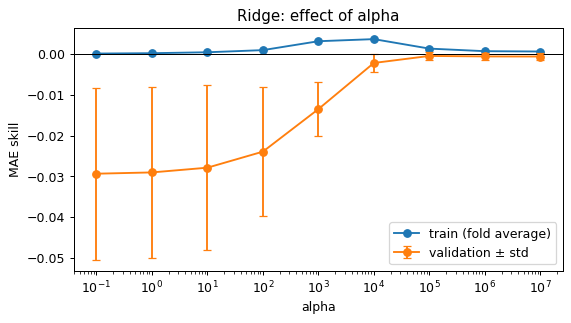

Ridge {'alpha': 100000}            MAE=0.3252  skill=-0.0003  R2oos=-0.0002  IC=+0.003  HourDir=0.503  DayDir=0.534 (p=0.01)  DayBalAcc=0.500


In [8]:
make_ridge = lambda alpha: make_pipeline(StandardScaler(), Ridge(alpha=alpha))
ridge_cv = cv_tune(make_ridge, {"alpha": [0.1, 1, 10, 100, 1_000, 10_000, 100_000, 1_000_000, 10_000_000]})

t = ridge_cv.sort_values("alpha")
plt.figure(figsize=(7, 3.5))
plt.semilogx(t["alpha"], t["train_skill"], "o-", label="train (fold average)")
plt.errorbar(t["alpha"], t["val_skill"], yerr=t["val_skill_std"], fmt="o-", capsize=3, label="validation ± std")
plt.axhline(0, color="k", lw=0.8)
plt.xlabel("alpha"); plt.ylabel("MAE skill"); plt.title("Ridge: effect of alpha"); plt.legend(); plt.show()

p_ridge = best_params(ridge_cv, ["alpha"])
ridge_model = final_report(f"Ridge {p_ridge}", make_ridge(**p_ridge))

### 7.2 Lasso regression

Like Ridge but with an L1 penalty, which sets some coefficients exactly to 0. It doubles as **feature selection**: the features it keeps are the ones with the most linear signal. If it removes everything, that tells you it found nothing better than the average.

| Hyperparameter | Effect | Grid |
|---|---|---|
| `alpha` | Penalty strength; larger means fewer features kept | 0.003 → 0.3 |

In [9]:
make_lasso = lambda alpha: make_pipeline(StandardScaler(), Lasso(alpha=alpha, max_iter=5000))
lasso_cv = cv_tune(make_lasso, {"alpha": [0.003, 0.01, 0.03, 0.1, 0.3]})
p_lasso = best_params(lasso_cv, ["alpha"])
lasso_model = final_report(f"Lasso {p_lasso}", make_lasso(**p_lasso))

coef = pd.DataFrame(lasso_model[-1].coef_.T, index=feature_names)        # features x 24 hours
kept = coef.abs().sum(axis=1)
print(f"\nLasso keeps {(kept > 0).sum()} of {len(kept)} features (non-zero for at least one hour).")
if (kept > 0).any():
    print("Strongest kept features:", list(kept[kept > 0].sort_values(ascending=False).head(8).index))
else:
    print("Lasso removed every feature: the best it found is to predict the average return for each hour.")

,alpha,train_skill,val_skill,val_skill_std,val_MAE,val_IC,val_DayDirAcc,seconds
0,0.100,0.0006,-0.0006,0.0009,0.4353,0.0107,0.5151,0.1
1,0.300,0.0006,-0.0006,0.0009,0.4353,0.0067,0.5151,0.1
2,0.030,0.0028,-0.0022,0.0036,0.4360,0.0200,0.5158,0.2
3,0.010,0.0037,-0.0116,0.0127,0.4400,0.0221,0.5090,0.4
4,0.003,0.0019,-0.0209,0.0176,0.4440,0.0212,0.5024,1.0


Lasso {'alpha': 0.1}               MAE=0.3252  skill=-0.0004  R2oos=-0.0003  IC=+0.000  HourDir=0.504  DayDir=0.534 (p=0.01)  DayBalAcc=0.500

Lasso keeps 0 of 42 features (non-zero for at least one hour).
Lasso removed every feature: the best it found is to predict the average return for each hour.


### 7.3 k-Nearest Neighbors

Finds the *k* past weeks most similar to the current one and averages what happened the day after: "history rhymes". It has no real training phase, so it is very easy to explain. Scaling matters because it is distance-based.

| Hyperparameter | Effect | Grid |
|---|---|---|
| `n_neighbors` | Few neighbours: noisy forecasts. Many: smooth, close to the average. (Must stay below the size of the smallest training fold, ≈1,950.) | 10, 50, 200, 500, 1000 |
| `weights` | `uniform`: all neighbours count equally. `distance`: closer ones count more. | both |

Note: with `weights="distance"` the train MAE is ≈ 0, because every training point is its own nearest neighbour. Only the validation MAE is meaningful there.

In [10]:
make_knn = lambda n_neighbors, weights: make_pipeline(
    StandardScaler(), KNeighborsRegressor(n_neighbors=n_neighbors, weights=weights))
knn_cv = cv_tune(make_knn, {"n_neighbors": [10, 50, 200, 500, 1000], "weights": ["uniform", "distance"]})
p_knn = best_params(knn_cv, ["n_neighbors", "weights"])
knn_model = final_report(f"KNN {p_knn}", make_knn(**p_knn))

,n_neighbors,weights,train_skill,val_skill,val_skill_std,val_MAE,val_IC,val_DayDirAcc,seconds
0,1000,uniform,0.0016,-0.0010,0.0012,0.4355,0.0069,0.4990,9.8
1,1000,distance,1.0000,-0.0010,0.0013,0.4355,0.0081,0.4997,11.8
2,500,distance,1.0000,-0.0024,0.0026,0.4361,0.0108,0.4996,6.7
3,500,uniform,0.0024,-0.0024,0.0026,0.4361,0.0098,0.4994,5.6
4,200,distance,1.0000,-0.0055,0.0043,0.4373,0.0132,0.5025,3.4
5,200,uniform,0.0039,-0.0055,0.0043,0.4373,0.0125,0.5029,3.0
6,50,distance,1.0000,-0.0203,0.0107,0.4434,0.0150,0.5060,1.5
7,50,uniform,0.0092,-0.0203,0.0108,0.4434,0.0148,0.5078,1.4
8,10,uniform,0.0430,-0.0859,0.0337,0.4708,0.0100,0.4913,1.0
9,10,distance,1.0000,-0.0859,0.0334,0.4708,0.0102,0.4925,1.0


KNN {'n_neighbors': 1000, 'weights': 'uniform'} MAE=0.3254  skill=-0.0010  R2oos=-0.0010  IC=+0.001  HourDir=0.501  DayDir=0.503 (p=0.44)  DayBalAcc=0.485


### 7.4 Random Forest

An average of many decision trees, each trained on a random sample of the data and of the features. It captures non-linear effects (for example "after a big drop in a calm week…") and predicts the 24 hours together. No scaling needed.

| Hyperparameter | Effect | Grid |
|---|---|---|
| `max_depth` | How many questions each tree may ask. The main overfitting control. | 4, 8, 16 |
| `min_samples_leaf` | Minimum number of samples per final leaf. Larger values give smoother, more cautious forecasts. | 20, 100 |
| `max_features` | Share of features considered at each split. Lower values give more varied trees (and faster training). | 0.3, 0.6 |
| `n_estimators` | Number of trees. More trees means more stable results, never more overfitting, only slower. | 50 for tuning (to save time), 300 for the final model |

,max_depth,max_features,min_samples_leaf,train_skill,val_skill,val_skill_std,val_MAE,val_IC,val_DayDirAcc,seconds
0,4,0.3,100,0.0032,-0.0012,0.0013,0.4356,0.0061,0.5134,4.2
1,4,0.3,20,0.0042,-0.0013,0.0012,0.4356,0.0197,0.5153,4.1
2,4,0.6,100,0.0033,-0.0013,0.0012,0.4356,0.0064,0.5114,7.5
3,4,0.6,20,0.0042,-0.0013,0.0011,0.4356,0.0215,0.5149,8.1
4,8,0.3,100,0.0056,-0.0018,0.0021,0.4358,0.0099,0.5069,7.1
5,8,0.6,100,0.0057,-0.0019,0.0020,0.4359,0.0110,0.5080,13.2
6,16,0.3,100,0.0077,-0.0019,0.0021,0.4359,0.0120,0.4979,10.6
7,16,0.6,100,0.0079,-0.0021,0.0022,0.4360,0.0134,0.5000,20.5
8,8,0.6,20,0.0077,-0.0022,0.0016,0.4360,0.0201,0.5157,15.0
9,8,0.3,20,0.0077,-0.0022,0.0016,0.4360,0.0174,0.5149,7.9


Random Forest {'max_depth': 4, 'min_samples_leaf': 100, 'max_features': 0.3} MAE=0.3252  skill=-0.0003  R2oos=-0.0002  IC=+0.003  HourDir=0.503  DayDir=0.534 (p=0.01)  DayBalAcc=0.500


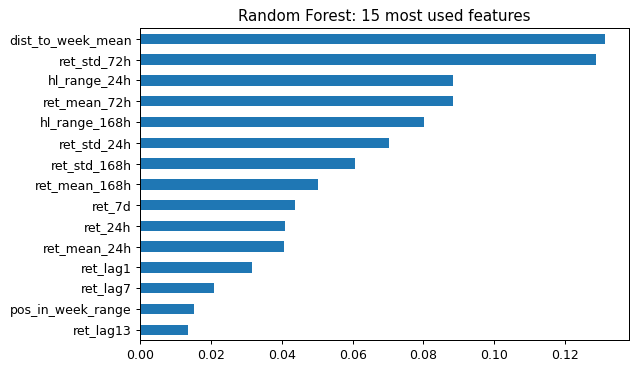

In [11]:
make_rf = lambda **p: RandomForestRegressor(n_estimators=50, n_jobs=-1, random_state=RANDOM_STATE, **p)
rf_cv = cv_tune(make_rf, {"max_depth": [4, 8, 16], "min_samples_leaf": [20, 100], "max_features": [0.3, 0.6]})
p_rf = best_params(rf_cv, ["max_depth", "min_samples_leaf", "max_features"])
rf_model = final_report(f"Random Forest {p_rf}",
                        RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE, **p_rf))

imp = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values()
imp.tail(15).plot.barh(figsize=(7, 4.5), title="Random Forest: 15 most used features"); plt.show()

Feature importance shows which inputs the forest *uses*, not that they actually predict well. Trees also split on noise. Volatility features usually come out on top: they help the forest decide how large its forecasts should be, not which direction.

### 7.5 Gradient Boosting (HistGradientBoostingRegressor)

Trees are built one after another, each correcting the errors of the previous ones. It is usually the strongest classical model on tabular data. It predicts one target at a time, so `MultiOutputRegressor` trains 24 models (one per hour), which makes it the slowest model here, so the grid is small. `loss="absolute_error"` makes it optimise MAE directly, which is robust to extreme hours.

| Hyperparameter | Effect | Grid |
|---|---|---|
| `learning_rate` | How strongly each new tree corrects. Smaller is more cautious and needs more trees. | 0.03, 0.1 |
| `max_depth` | Complexity of each tree | 2, 4 |
| `max_iter` + `early_stopping` | Maximum number of trees. Training stops early when an internal validation score stops improving. | 200 |
| `min_samples_leaf` | Smoothness, as in the Random Forest | 200 |

In [12]:
make_hgb = lambda **p: MultiOutputRegressor(HistGradientBoostingRegressor(
    loss="absolute_error", max_iter=200, min_samples_leaf=200, early_stopping=True,
    random_state=RANDOM_STATE, **p))
hgb_cv = cv_tune(make_hgb, {"learning_rate": [0.03, 0.1], "max_depth": [2, 4]})
p_hgb = best_params(hgb_cv, ["learning_rate", "max_depth"])
hgb_model = final_report(f"Gradient Boosting {p_hgb}", make_hgb(**p_hgb))

,learning_rate,max_depth,train_skill,val_skill,val_skill_std,val_MAE,val_IC,val_DayDirAcc,seconds
0,0.03,2,0.0058,-0.0015,0.0031,0.4357,0.0136,0.5149,7.4
1,0.03,4,0.0111,-0.0018,0.0031,0.4358,0.0128,0.5148,9.5
2,0.10,2,0.0114,-0.0026,0.0044,0.4362,0.0147,0.5163,6.6
3,0.10,4,0.0210,-0.0040,0.0054,0.4367,0.0171,0.5175,7.5


Gradient Boosting {'learning_rate': 0.03, 'max_depth': 2} MAE=0.3252  skill=-0.0004  R2oos=-0.0007  IC=+0.005  HourDir=0.505  DayDir=0.535 (p=0.01)  DayBalAcc=0.501


### 7.6 (Optional) small MLP from scikit-learn

A small ready-made feed-forward network: we only choose its size and penalty and do not build anything ourselves. Check with your teacher whether it fits the course rules, and skip it if not.

| Hyperparameter | Effect | Grid |
|---|---|---|
| `hidden_layer_sizes` | Neurons per layer | (32,), (64, 32) |
| `alpha` | L2 penalty, as in Ridge | 0.01, 1, 10, 100 |
| `early_stopping` | Stops when an internal validation score stops improving | on |

In [13]:
make_mlp = lambda **p: make_pipeline(StandardScaler(), MLPRegressor(
    max_iter=300, early_stopping=True, random_state=RANDOM_STATE, **p))
mlp_cv = cv_tune(make_mlp, {"hidden_layer_sizes": [(32,), (64, 32)], "alpha": [0.01, 1.0, 10.0, 100.0]})
p_mlp = best_params(mlp_cv, ["hidden_layer_sizes", "alpha"])
mlp_model = final_report(f"MLP {p_mlp}", make_mlp(**p_mlp))

,alpha,hidden_layer_sizes,train_skill,val_skill,val_skill_std,val_MAE,val_IC,val_DayDirAcc,seconds
0,100.00,"(32,)",0.0008,-0.0007,0.0010,0.4354,0.0079,0.5151,1.6
1,100.00,"(64, 32)",0.0001,-0.0018,0.0021,0.4358,0.0046,0.5151,1.9
2,10.00,"(64, 32)",0.0047,-0.0058,0.0083,0.4375,0.0164,0.5121,2.5
3,10.00,"(32,)",0.0051,-0.0145,0.0146,0.4413,0.0204,0.5019,2.2
4,1.00,"(64, 32)",-0.0033,-0.0252,0.0191,0.4458,0.0093,0.5166,1.9
5,0.01,"(64, 32)",-0.0046,-0.0276,0.0185,0.4468,0.0102,0.5127,1.8
6,1.00,"(32,)",-0.0053,-0.0385,0.0230,0.4514,0.0155,0.4991,1.9
7,0.01,"(32,)",-0.0066,-0.0422,0.0244,0.4529,0.0154,0.4996,1.9


MLP {'hidden_layer_sizes': (32,), 'alpha': 100} MAE=0.3254  skill=-0.0008  R2oos=-0.0007  IC=+0.001  HourDir=0.502  DayDir=0.534 (p=0.01)  DayBalAcc=0.500


## 8. Experiment: how much history should we train on?

Decision (b) said "train from 2017". Here we test it. The best Ridge is trained from different start years, always validated on the **last year of the training period** (Oct 2022 → Oct 2023). The test period is not touched, so this choice stays honest.

More data is usually better, but only if the old data behaves like the new data.

In [14]:
val_start = Dtr[-1] - pd.Timedelta(days=365)
gap_time = pd.Timedelta(hours=INPUT_HOURS + TARGET_HOURS)
rows = []
for start in ["2012-01-01", "2014-01-01", "2017-01-01", "2019-01-01", "2021-01-01"]:
    tr = (D_all >= pd.Timestamp(start)) & (D_all < val_start - gap_time)
    va = D_all >= val_start
    m = make_ridge(**p_ridge).fit(F_all[tr], Y_all[tr])
    rows.append({"train_from": start, "n_train": tr.sum(), **metrics(Y_all[va], m.predict(F_all[va]))})
hist = pd.DataFrame(rows).set_index("train_from")
display(hist[["n_train", "MAE", "MAE_skill", "IC", "DayDirAcc"]].round(4))

,n_train,MAE,MAE_skill,IC,DayDirAcc
train_from,,,,,
2012-01-01,15733,0.2665,-0.0019,-0.0243,0.5092
2014-01-01,12841,0.2662,-0.0007,-0.0103,0.5106
2017-01-01,8457,0.2662,-0.0009,-0.0098,0.5099
2019-01-01,5537,0.2663,-0.0011,-0.0073,0.5099
2021-01-01,2613,0.2664,-0.0016,-0.0083,0.5113


## 9. Final comparison on the test period (Oct 2023 → Oct 2026)

`DayDirAcc_indep` and `p_value` come from the ≈1,080 non-overlapping test days (layer 3 of the validation).

,MAE,RMSE,MAE_skill,R2_oos,IC,HourDirAcc,DayDirAcc_indep,p_value,DayBalAcc_indep
Model,,,,,,,,,
Baseline: last-hour reversal,0.3251,0.5006,0.0001,-0.0001,0.0020,0.4947,0.5074,0.3237,0.5083
Baseline: zero,0.3251,0.5005,0.0000,0.0000,NaN,0.4934,0.4656,0.9889,0.5000
"Random Forest {'max_depth': 4, 'min_samples_leaf': 100, 'max_features': 0.3}",0.3252,0.5006,-0.0003,-0.0002,0.0033,0.5031,0.5344,0.0130,0.5000
Ridge {'alpha': 100000},0.3252,0.5006,-0.0003,-0.0002,0.0035,0.5025,0.5344,0.0130,0.5000
Baseline: mean per hour,0.3252,0.5006,-0.0004,-0.0003,0.0000,0.5044,0.5344,0.0130,0.5000
Lasso {'alpha': 0.1},0.3252,0.5006,-0.0004,-0.0003,0.0000,0.5044,0.5344,0.0130,0.5000
"Gradient Boosting {'learning_rate': 0.03, 'max_depth': 2}",0.3252,0.5007,-0.0004,-0.0007,0.0048,0.5055,0.5353,0.0111,0.5011
"MLP {'hidden_layer_sizes': (32,), 'alpha': 100}",0.3254,0.5007,-0.0008,-0.0007,0.0013,0.5024,0.5344,0.0130,0.5000
"KNN {'n_neighbors': 1000, 'weights': 'uniform'}",0.3254,0.5008,-0.0010,-0.0010,0.0008,0.5010,0.5028,0.4394,0.4848


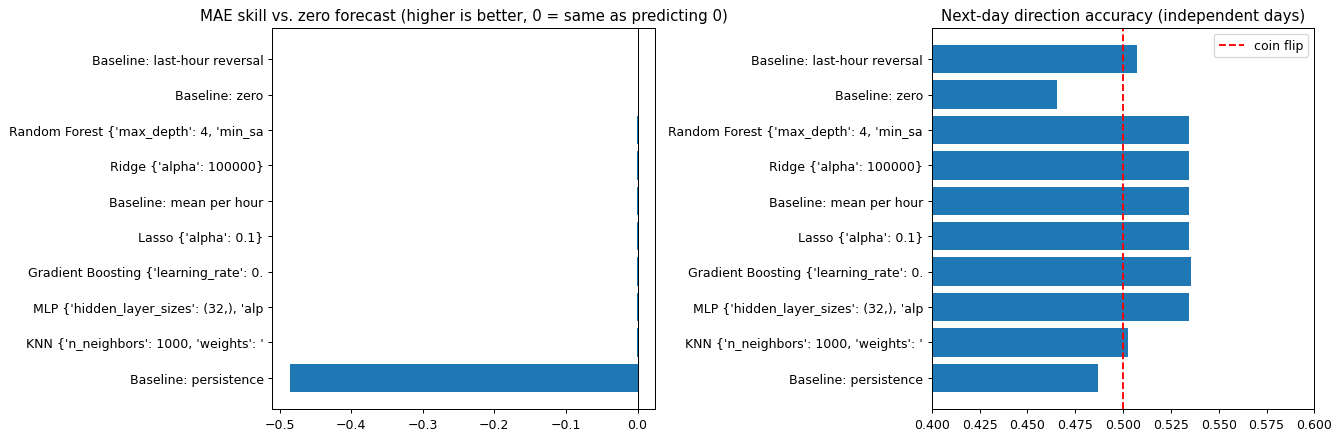

In [15]:
summary = pd.DataFrame(results).drop_duplicates("Model", keep="last").set_index("Model")
cols = ["MAE", "RMSE", "MAE_skill", "R2_oos", "IC", "HourDirAcc", "DayDirAcc_indep", "p_value", "DayBalAcc_indep"]
display(summary[cols].sort_values("MAE").round(4))

s = summary.sort_values("MAE_skill")
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].barh(s.index.str.slice(0, 38), s["MAE_skill"]); ax[0].axvline(0, color="k", lw=0.8)
ax[0].set_title("MAE skill vs. zero forecast (higher is better, 0 = same as predicting 0)")
ax[1].barh(s.index.str.slice(0, 38), s["DayDirAcc_indep"]); ax[1].axvline(0.5, color="red", ls="--", label="coin flip")
ax[1].set_xlim(0.4, 0.6); ax[1].set_title("Next-day direction accuracy (independent days)"); ax[1].legend()
plt.tight_layout(); plt.show()

**Error by forecast horizon.** Is the first hour (closest to the data) more predictable than hour 24? The plot shows the MAE skill for each of the 24 predicted hours.

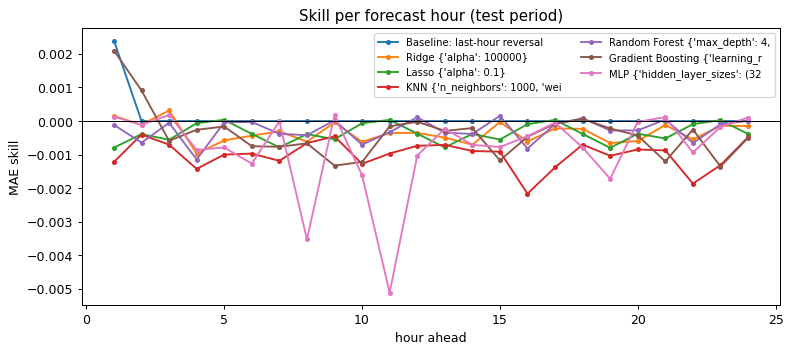

In [16]:
plt.figure(figsize=(10, 4))
mae0_h = np.abs(Yte).mean(axis=0)
for name, pred in test_preds.items():
    if name.startswith("Baseline") and "reversal" not in name:
        continue
    plt.plot(range(1, 25), 1 - np.abs(Yte - pred).mean(axis=0) / mae0_h, marker=".", label=name[:30])
plt.axhline(0, color="k", lw=0.8)
plt.xlabel("hour ahead"); plt.ylabel("MAE skill"); plt.title("Skill per forecast hour (test period)")
plt.legend(fontsize=8, ncol=2); plt.show()

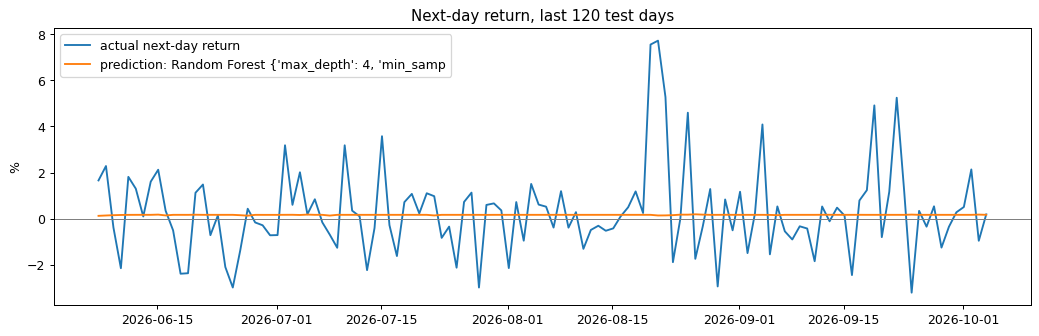

In [17]:
# Predicted vs. actual next-day return over the last 120 test days, for the best model by MAE skill
best_name = summary.drop([i for i in summary.index if i.startswith("Baseline")])["MAE_skill"].idxmax()
days = np.arange(len(Yte) - 120 * 24, len(Yte), 24)
plt.figure(figsize=(14, 4))
plt.plot(Dte[days], daily_from_hourly(Yte[days]), label="actual next-day return")
plt.plot(Dte[days], daily_from_hourly(test_preds[best_name][days]), label=f"prediction: {best_name[:40]}")
plt.axhline(0, color="grey", lw=0.8); plt.ylabel("%"); plt.legend()
plt.title("Next-day return, last 120 test days"); plt.show()

The prediction line is almost flat compared to reality. This is not a bug: when a model cannot tell what will happen, the forecast that minimises the error is a value close to zero. The models "know that they don't know".

## 10. Better targets

The 24-hour target has three weaknesses:

1. **It is almost pure noise.** Each hourly move is tiny compared to its randomness, so every model collapses towards zero and the comparison between models becomes hard to see.
2. **24 outputs are expensive.** Gradient Boosting has to train 24 models, and the 24 errors are summed even though users mostly care about the day as a whole.
3. **Simple returns are not additive.** +10% then −10% is not 0%. Log returns `ln(1 + r)` fix this: the daily log return is simply the sum of the 24 hourly log returns.

All the alternatives below are built from the **same** `y` arrays, so the data preparation does not need to change.

| Alternative target | Type | Why it can be better | What to expect |
|---|---|---|---|
| **A. Next-day log return** = Σ ln(1 + r_h) | regression, 1 value | Same information as the 24 values for anyone who cares about the day. 24× cheaper to train, simpler to explain. Additive. | Still mostly noise: skill ≈ 0, R²_oos ≈ 0 |
| **B. Next-day direction** (up / down) | classification | Directly answers the question people ask. Lets you use classifiers and metrics like accuracy and ROC AUC, which are well covered in basic ML courses. | AUC ≈ 0.50–0.53, accuracy ≈ 50% |
| **C. Next-day volatility** = log of the realized volatility √Σ(ln(1 + r_h))² | regression, 1 value | **Volatility is predictable** (calm days follow calm days, wild days follow wild days, the so-called *volatility clustering*). Models show clear, measurable skill, so hyperparameter effects become visible. Useful in practice for risk management. | R² ≈ 0.3–0.6, clearly above the baselines |

**Recommendation.** Keep the 24-hour return target as the main task (it is the assigned problem), but add **C (volatility)** as a second experiment. It shows the methods working when there *is* signal, and contrasts it with returns, where there is none. That makes a much stronger conclusion than "nothing beats zero". Targets A and B are cheap extras that make the return results easier to present.

For these single-value targets we use scikit-learn's own `GridSearchCV` with the same walk-forward `folds`. It does the same as `cv_tune`, with less code.

In [18]:
def daily_log_return(y_pct):
    return np.log1p(y_pct / 100).sum(axis=1) * 100

def log_realized_vol(y_pct):
    lr = np.log1p(y_pct / 100) * 100
    return np.log(np.sqrt((lr ** 2).sum(axis=1)) + 1e-6)

test_days = np.arange(0, len(Yte), 24)      # evaluate single-value targets on independent days

def tune_and_test(estimator, grid, y_tr, y_te, scoring):
    gs = GridSearchCV(estimator, grid, cv=folds, scoring=scoring, n_jobs=-1).fit(Ftr, y_tr)
    return gs.best_params_, gs.best_estimator_.predict(Fte[test_days]), gs

# next-day log return (used by targets A and B)
ya_tr, ya_te = daily_log_return(Ytr), daily_log_return(Yte)[test_days]

### 10.A Next-day log return (one value)

Metrics: MAE, MAE skill and R²_oos against the zero forecast, IC and direction accuracy, all as in section 4. Note that the numbers are now in "% per day", so the MAE is roughly 5× larger than the hourly one.

In [19]:
def report_A(name, pred):
    mae, mae0 = mean_absolute_error(ya_te, pred), np.abs(ya_te).mean()
    print(f"{name:<45} MAE={mae:.3f}  skill={1 - mae / mae0:+.4f}  "
          f"R2oos={1 - ((ya_te - pred) ** 2).sum() / (ya_te ** 2).sum():+.4f}  "
          f"IC={safe_corr(pred, ya_te):+.3f}  DirAcc={((pred > 0) == (ya_te > 0)).mean():.3f}")

report_A("Baseline: zero", np.zeros_like(ya_te))
for name, est, grid in [
    ("Ridge", make_pipeline(StandardScaler(), Ridge()), {"ridge__alpha": [1, 100, 1_000, 10_000, 100_000]}),
    ("Random Forest", RandomForestRegressor(n_estimators=200, max_features=0.3, n_jobs=-1, random_state=RANDOM_STATE),
     {"max_depth": [3, 6, 10], "min_samples_leaf": [50, 200]}),
    ("Gradient Boosting", HistGradientBoostingRegressor(loss="absolute_error", early_stopping=True, random_state=RANDOM_STATE),
     {"learning_rate": [0.03, 0.1], "max_depth": [2, 4], "min_samples_leaf": [100, 300]}),
]:
    params, pred, _ = tune_and_test(est, grid, ya_tr, ya_te, "neg_mean_absolute_error")
    report_A(f"{name} {params}", pred)

Baseline: zero                                MAE=1.706  skill=+0.0000  R2oos=+0.0000  IC=+nan  DirAcc=0.465
Ridge {'ridge__alpha': 10000}                 MAE=1.703  skill=+0.0019  R2oos=+0.0092  IC=+0.094  DirAcc=0.516
Random Forest {'max_depth': 3, 'min_samples_leaf': 200} MAE=1.716  skill=-0.0063  R2oos=+0.0007  IC=+0.040  DirAcc=0.485
Gradient Boosting {'learning_rate': 0.03, 'max_depth': 4, 'min_samples_leaf': 100} MAE=1.699  skill=+0.0042  R2oos=+0.0037  IC=+0.057  DirAcc=0.521


### 10.B Next-day direction (classification)

Metrics for classification:

| Metric | Meaning | Expected |
|---|---|---|
| **Accuracy** | Share of days with the correct direction | ≈ 50%. Compare with "always up", which already gets the share of up days. |
| **Balanced accuracy** | Average of the accuracy on up days and on down days, so a model cannot look good by always saying "up" | 0.5 = no skill |
| **ROC AUC** | Probability that the model gives a higher "up" probability to a random up day than to a random down day | 0.5 = no skill; 0.52–0.55 would be a good result |
| **Log loss** | How good the predicted probabilities are; it punishes confident wrong answers | ln 2 ≈ 0.693 for always saying 50/50. Lower is better. |

Hyperparameters are chosen by ROC AUC, because accuracy can be "won" by always predicting the majority class.

In [20]:
yb_tr, yb_te = (ya_tr > 0).astype(int), (ya_te > 0).astype(int)
print(f"Share of up days: train {yb_tr.mean():.3f}, test {yb_te.mean():.3f}")

def report_B(name, proba):
    pred = (proba > 0.5).astype(int)
    print(f"{name:<55} acc={accuracy_score(yb_te, pred):.3f}  bal_acc={balanced_accuracy_score(yb_te, pred):.3f}  "
          f"AUC={roc_auc_score(yb_te, proba) if np.std(proba) > 0 else 0.5:.3f}  "
          f"logloss={log_loss(yb_te, np.clip(proba, 1e-6, 1 - 1e-6)):.3f}")

report_B("Baseline: always up (train up-share as probability)", np.full(len(yb_te), yb_tr.mean()))
for name, est, grid in [
    ("Logistic Regression", make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
     {"logisticregression__C": [0.000001, 0.00001, 0.0001, 0.001, 0.01]}),
    ("Random Forest", RandomForestClassifier(n_estimators=200, max_features=0.3, n_jobs=-1, random_state=RANDOM_STATE),
     {"max_depth": [3, 6, 10], "min_samples_leaf": [50, 200]}),
    ("Gradient Boosting", HistGradientBoostingClassifier(early_stopping=True, random_state=RANDOM_STATE),
     {"learning_rate": [0.03, 0.1], "max_depth": [2, 4], "min_samples_leaf": [100, 300]}),
]:
    gs = GridSearchCV(est, grid, cv=folds, scoring="roc_auc", n_jobs=-1).fit(Ftr, yb_tr)
    report_B(f"{name} {gs.best_params_}", gs.best_estimator_.predict_proba(Fte[test_days])[:, 1])

Share of up days: train 0.528, test 0.535
Baseline: always up (train up-share as probability)     acc=0.535  bal_acc=0.500  AUC=0.500  logloss=0.691
Logistic Regression {'logisticregression__C': 1e-06}    acc=0.535  bal_acc=0.500  AUC=0.540  logloss=0.691
Random Forest {'max_depth': 6, 'min_samples_leaf': 200} acc=0.525  bal_acc=0.512  AUC=0.529  logloss=0.690
Gradient Boosting {'learning_rate': 0.1, 'max_depth': 2, 'min_samples_leaf': 300} acc=0.520  bal_acc=0.506  AUC=0.520  logloss=0.691


### 10.C Next-day volatility

Target: the log of the next day's realized volatility, `ln √Σ(ln(1 + r_h))²` (in %). The log makes the distribution symmetric, so a calm day and a wild day are treated more evenly.

Baselines from volatility research: **yesterday's volatility** (persistence) and the **average over the past week**. Here the usual R² (against the test mean) is the right metric, because the question is how much of the day-to-day variation in volatility the model explains.

| Metric | Meaning | Expected |
|---|---|---|
| **MAE (log vol)** | Average error in log units; 0.3 ≈ "off by about 30%" | lower is better; baselines ≈ 0.3–0.4 |
| **R²** | Share of the variation in volatility explained | 0 = no better than a constant; 0.3–0.6 is realistic here |

In [21]:
yc_tr, yc_te = log_realized_vol(Ytr), log_realized_vol(Yte)[test_days]
lr_in = np.log1p(Rte[test_days] / 100) * 100                     # input-week log returns (%)

def report_C(name, pred):
    print(f"{name:<55} MAE={mean_absolute_error(yc_te, pred):.3f}  R2={r2_score(yc_te, pred):.3f}  "
          f"corr={safe_corr(pred, yc_te):.3f}")

report_C("Baseline: yesterday's volatility", np.log(np.sqrt((lr_in[:, -24:] ** 2).sum(1)) + 1e-6))
report_C("Baseline: average daily volatility of last week", np.log(np.sqrt((lr_in ** 2).sum(1) / 7) + 1e-6))
vol_models = {}
for name, est, grid in [
    ("Ridge", make_pipeline(StandardScaler(), Ridge()), {"ridge__alpha": [0.001, 0.1, 10, 1_000]}),
    ("Random Forest", RandomForestRegressor(n_estimators=200, max_features=0.3, n_jobs=-1, random_state=RANDOM_STATE),
     {"max_depth": [6, 10, 16], "min_samples_leaf": [3, 10, 50]}),
    ("Gradient Boosting", HistGradientBoostingRegressor(early_stopping=True, random_state=RANDOM_STATE),
     {"learning_rate": [0.03, 0.1], "max_depth": [3, 6], "min_samples_leaf": [20, 100]}),
]:
    params, pred, gs = tune_and_test(est, grid, yc_tr, yc_te, "neg_mean_absolute_error")
    vol_models[name] = (gs, pred)
    report_C(f"{name} {params}", pred)

Baseline: yesterday's volatility                        MAE=0.412  R2=-0.141  corr=0.428
Baseline: average daily volatility of last week         MAE=0.360  R2=0.092  corr=0.447
Ridge {'ridge__alpha': 0.001}                           MAE=0.313  R2=0.338  corr=0.601
Random Forest {'max_depth': 10, 'min_samples_leaf': 10} MAE=0.292  R2=0.430  corr=0.657
Gradient Boosting {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 20} MAE=0.285  R2=0.454  corr=0.678


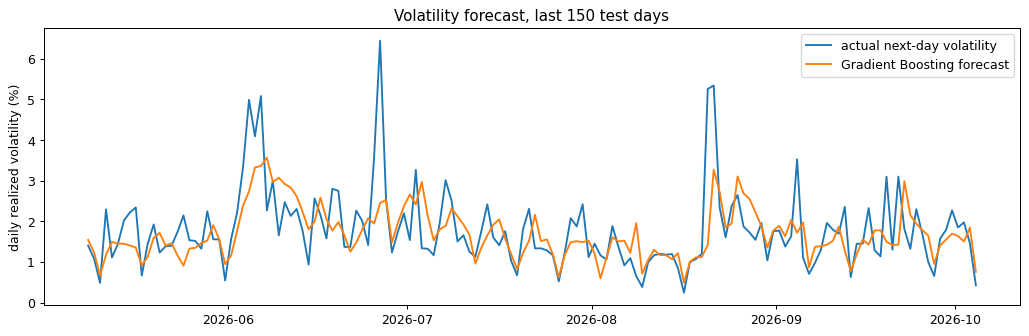

In [22]:
pred = vol_models["Gradient Boosting"][1]
last = slice(-150, None)
plt.figure(figsize=(14, 4))
plt.plot(Dte[test_days][last], np.exp(yc_te[last]), label="actual next-day volatility")
plt.plot(Dte[test_days][last], np.exp(pred[last]), label="Gradient Boosting forecast")
plt.ylabel("daily realized volatility (%)"); plt.title("Volatility forecast, last 150 test days"); plt.legend(); plt.show()

## 11. Conclusions

These conclusions come from the run on the data available on 5 October 2026 (test period 25 Oct 2023 → 5 Oct 2026). Exact numbers will change slightly if the data is refreshed.

**1. The assigned target (24 hourly returns) cannot be predicted better than "zero".**
On the test period the zero forecast has an MAE of 0.3251%. Every tuned model lands between 0.3252% and 0.3254%: MAE skill between −0.0003 and −0.0010, IC at most 0.005. This is the expected behaviour for hourly returns, which are very close to a random walk. It is a correct result, not a failure of the models.

**2. The direction numbers need care.** The tuned models show 53.4% daily direction accuracy with p ≈ 0.01, which looks significant. It is only because 53.5% of test days were up days: the models effectively predict "always up". Their balanced accuracy is exactly 0.50. The "mean per hour" baseline gives the same result.

**3. Hyperparameters behave as theory predicts, and that is the main learning outcome.**
- *Ridge / Lasso:* validation skill improves steadily as `alpha` grows. The best Ridge (alpha = 100,000) is almost the mean baseline, and the best Lasso (alpha = 0.1) removes every feature.
- *KNN:* more neighbours is always better (k = 10 gives skill −0.086, k = 1000 gives −0.001). Averaging more history means trusting individual patterns less.
- *Random Forest:* deeper trees with small leaves overfit. Depth 16 with leaf 20 has train skill +0.016 but validation skill −0.004, while depth 4 with leaf 100 is the best.
- *Gradient Boosting:* the same pattern. Learning rate 0.1 with depth 4 has train skill +0.021 but validation skill −0.004, while 0.03 with depth 2 is the best.
- *MLP:* weak regularization (alpha 0.01–1) overfits badly (validation skill down to −0.04); alpha = 100 brings it back near 0.

In every case, **the more a model is allowed to fit the training data, the worse it does on new periods.** That is the signature of a target that is mostly noise.

**4. How much history to use.** Training from 2012, 2014, 2017, 2019 or 2021 makes no meaningful difference: skills range from −0.0007 to −0.0019, a smaller spread than the variation between folds. Including 2012 gave the worst IC (−0.024), which supports leaving out the illiquid early years.

**5. Better targets.**
- *Next-day log return (A):* the first weak but real signal appears. Ridge reaches an IC of 0.094 and R²_oos of +0.009, and Gradient Boosting reaches MAE skill +0.004. Summing 24 noisy hours into one number cancels part of the noise.
- *Direction classification (B):* ROC AUC 0.52–0.54 against 0.50 for "always up". There is a little ranking information, but not enough to change accuracy. Logistic Regression picks the strongest penalty in its grid (C = 10⁻⁶): its probabilities stay close to the base rate, yet their ranking still carries the small signal.
- *Next-day volatility (C):* **the models clearly work.**

| Model | MAE (log vol) | R² | Correlation |
|---|---|---|---|
| Yesterday's volatility | 0.412 | −0.14 | 0.43 |
| Last week's average volatility | 0.360 | 0.09 | 0.45 |
| Ridge | 0.313 | 0.34 | 0.60 |
| Random Forest (depth 10, leaf 10) | 0.292 | 0.43 | 0.66 |
| Gradient Boosting (lr 0.1, depth 3, leaf 20) | **0.285** | **0.45** | **0.68** |

Here the non-linear models beat the linear one, and both beat the simple rules by a wide margin. (Ridge gives the same result for every small alpha, so its best value sitting at the grid edge does not matter.)

**Recommended story for the project:** "Hourly price changes are essentially unpredictable with basic ML, and walk-forward validation shows that more flexible models only overfit. Aggregating to one daily value reveals a weak signal. The size of tomorrow's moves (volatility), however, is predictable, and there Gradient Boosting explains about 45% of the variation."